/tmp/ipykernel_17852/2047381610.py:128: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', max(2, len(all_edges)))


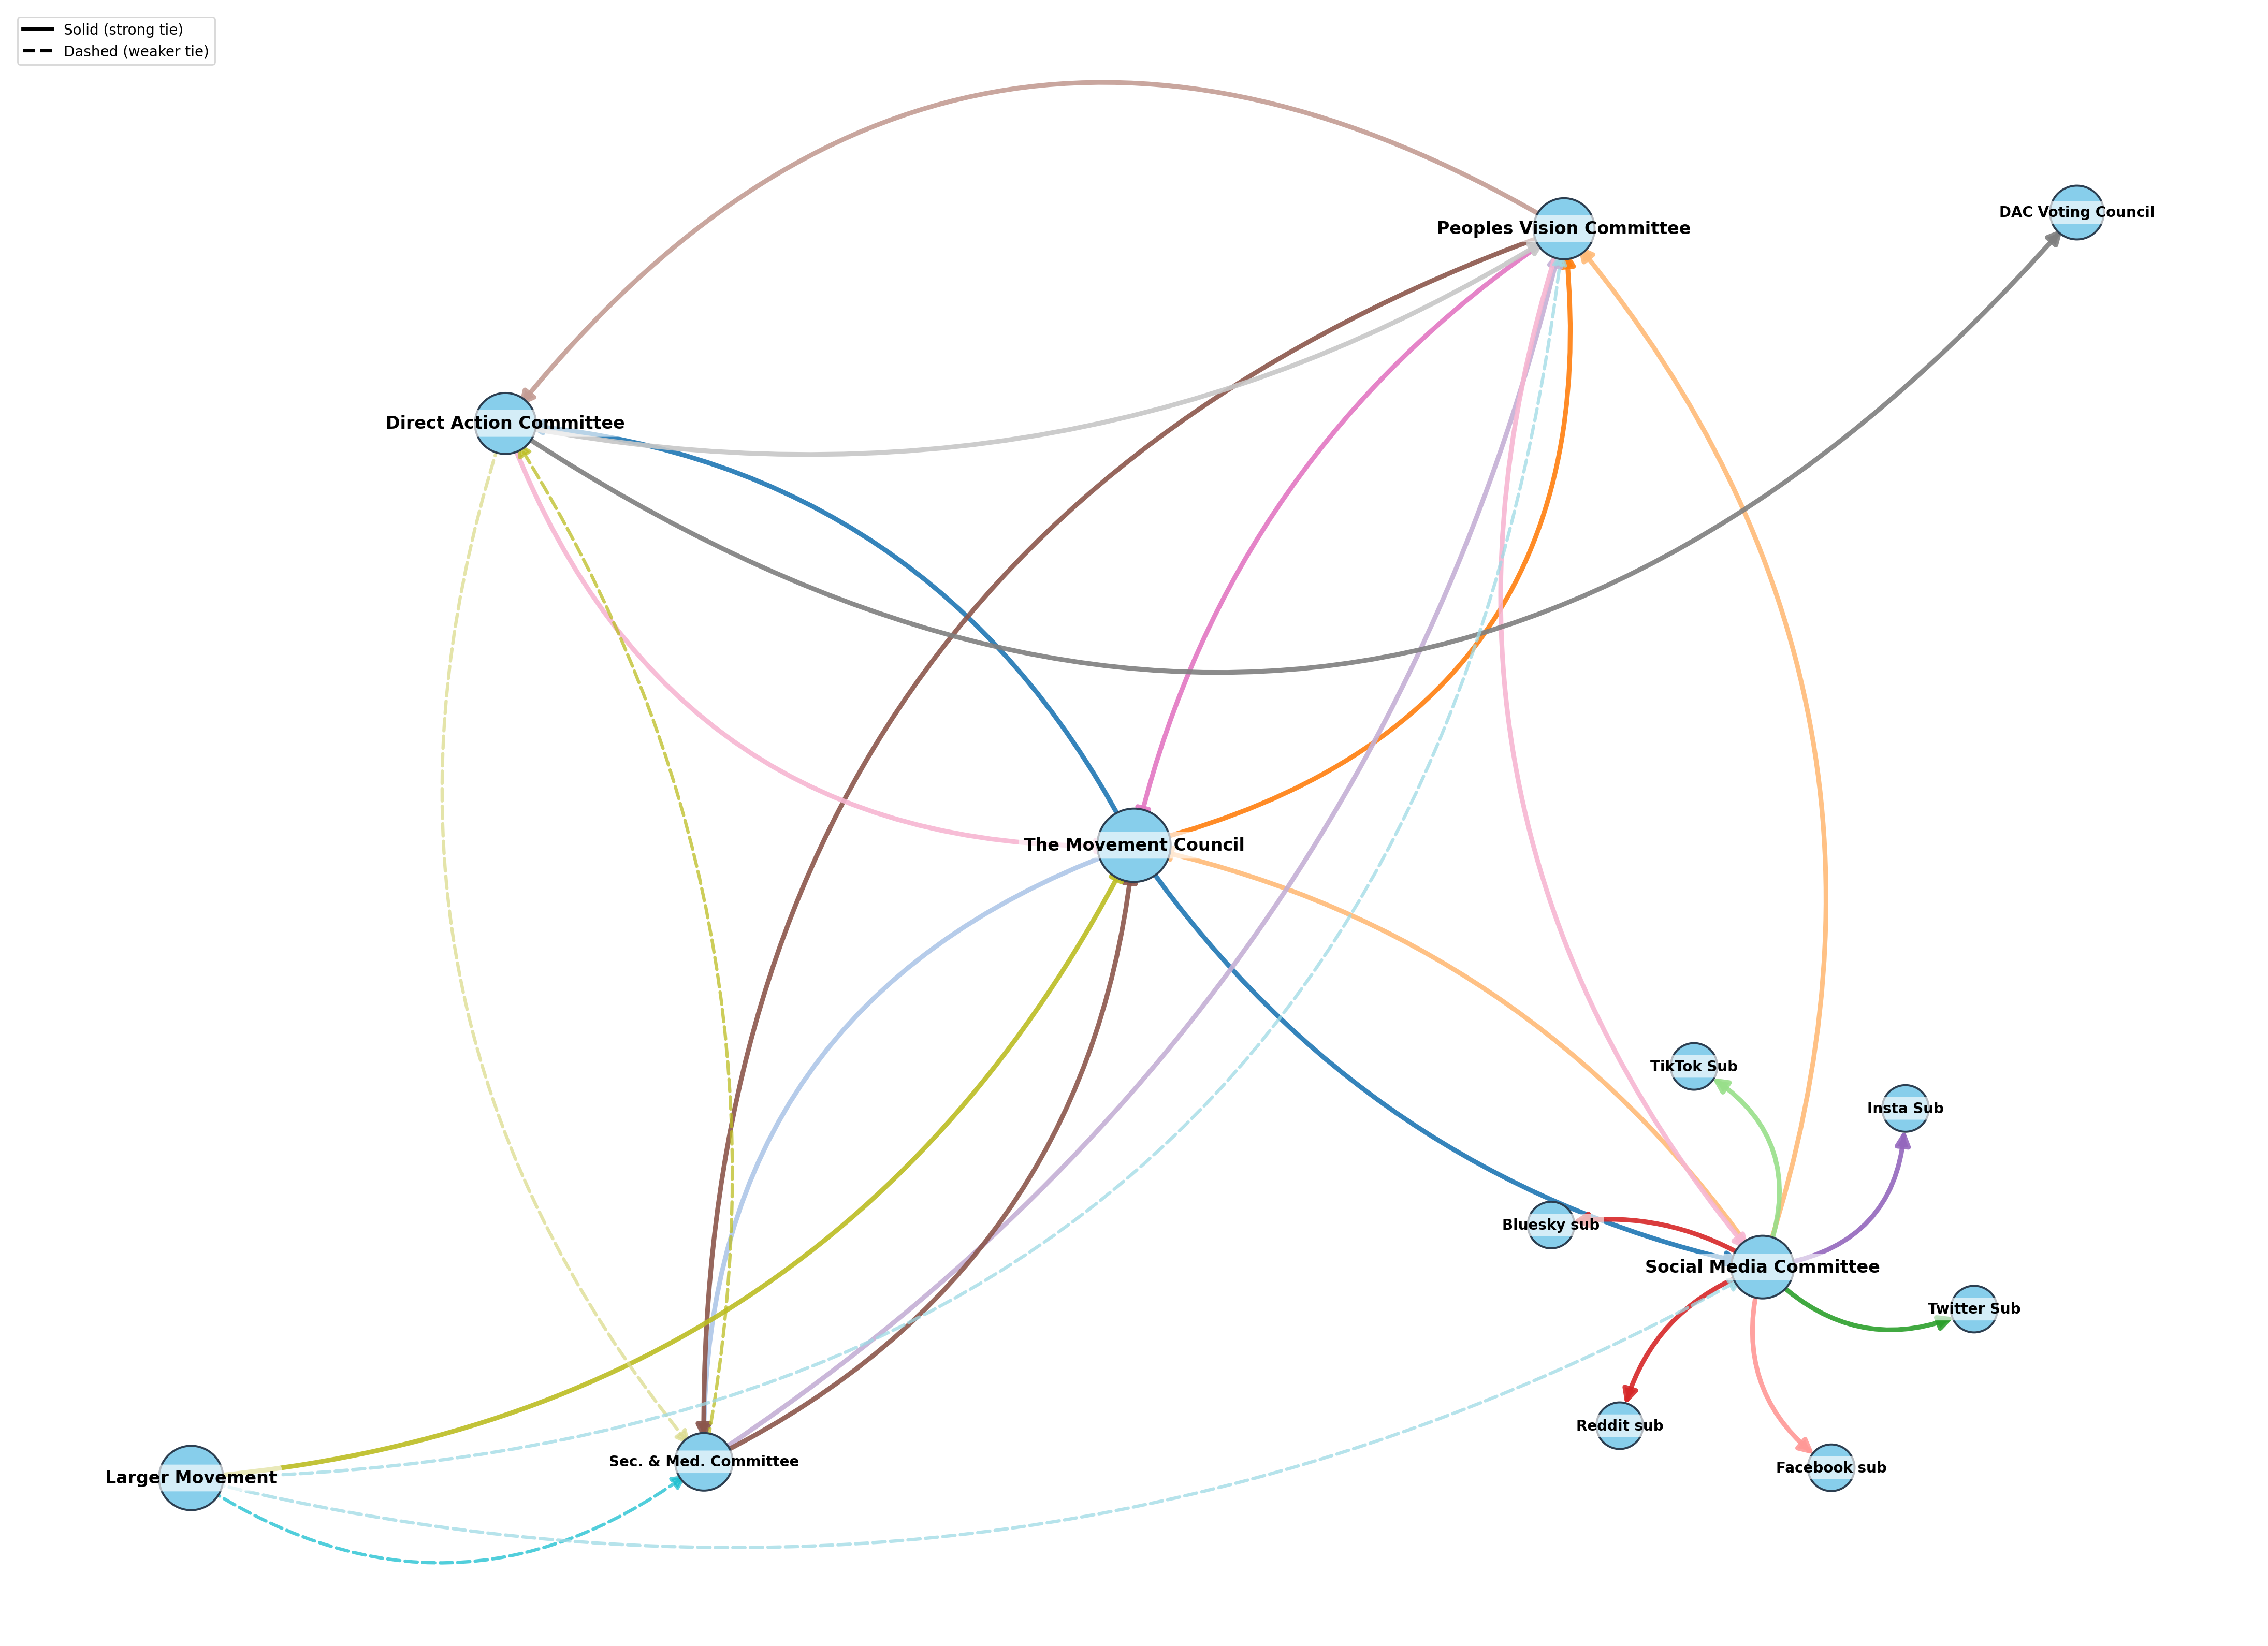

Saved to movement_graph_cluster_legible.png


In [30]:
# Movement graph — council center, committees on a wide ring,
# Social Media subs clustered tightly around SMC — with legibility fixes:
# - arrowheads offset from nodes (no truncation)
# - per-edge distinct colors
# - stronger curvature with varied arcs to reduce overlap

import math
import numpy as np
import matplotlib.cm as cm
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ------------------------------
# Build graph + visual metadata
# ------------------------------
G = nx.DiGraph()

node_size = {
    "The Movement Council": 2600,
    "Social Media Committee": 1900,
    "Sec. & Med. Committee": 1600,
    "Peoples Vision Committee": 1800,
    "Direct Action Committee": 1800,
    "DAC Voting Council": 1400,
    "Twitter Sub": 1050,
    "Insta Sub": 1050,
    "TikTok Sub": 1050,
    "Bluesky sub": 1050,
    "Reddit sub": 1050,
    "Facebook sub": 1050,
    "Larger Movement": 2000,
}
label_size = {n: (12 if node_size[n] >= 1800 else 10) for n in node_size}
G.add_nodes_from(node_size.keys())

def add(u, v, w=1.0, layout_w=None):
    if layout_w is None:
        layout_w = w
    G.add_edge(u, v, weight=w, layout_w=layout_w)

# Core ties
add("The Movement Council", "Social Media Committee", 1, layout_w=2.0)
add("The Movement Council", "Direct Action Committee", 1, layout_w=1.6)
add("The Movement Council", "Sec. & Med. Committee", 1, layout_w=1.6)
add("The Movement Council", "Peoples Vision Committee", 1, layout_w=1.6)

add("Sec. & Med. Committee", "Peoples Vision Committee", 1)
add("Sec. & Med. Committee", "The Movement Council", 1)
add("Sec. & Med. Committee", "Direct Action Committee", 0.5)  # weaker

add("Peoples Vision Committee", "Sec. & Med. Committee", 1)
add("Peoples Vision Committee", "Direct Action Committee", 1, layout_w=1.8)
add("Peoples Vision Committee", "The Movement Council", 1)
add("Peoples Vision Committee", "Social Media Committee", 1, layout_w=1.7)

add("Direct Action Committee", "The Movement Council", 1)
add("Direct Action Committee", "DAC Voting Council", 1, layout_w=1.8)
add("Direct Action Committee", "Peoples Vision Committee", 1)
add("Direct Action Committee", "Sec. & Med. Committee", 0.5)  # weaker

add("Social Media Committee", "The Movement Council", 1)
add("Social Media Committee", "Peoples Vision Committee", 1)

# SMC -> subs (tight local cluster)
for sub in ["Twitter Sub","TikTok Sub","Bluesky sub","Reddit sub","Facebook sub","Insta Sub"]:
    add("Social Media Committee", sub, 1, layout_w=3.0)

# Larger movement dotted ties
add("Larger Movement", "The Movement Council", 1)
add("Larger Movement", "Sec. & Med. Committee", 0.5)
add("Larger Movement", "Peoples Vision Committee", 0.5)
add("Larger Movement", "Social Media Committee", 0.5)

# ------------------------------
# Deterministic positions
# ------------------------------
center = "The Movement Council"
committees_order = [
    "Social Media Committee",
    "Peoples Vision Committee",
    "Direct Action Committee",
    "Sec. & Med. Committee",
]
smc_subs = ["Twitter Sub","Insta Sub","TikTok Sub","Bluesky sub","Reddit sub","Facebook sub"]
outer = ["DAC Voting Council","Larger Movement"]

R_COMMS = 3.0
R_SUBCLUSTER = 0.85
R_OUTER = 4.5
SMC_THETA = -0.6

def ring_positions(nodes, radius, theta0=0.0):
    if not nodes:
        return {}
    step = 2 * math.pi / len(nodes)
    return {
        node: (radius * math.cos(theta0 + i * step),
               radius * math.sin(theta0 + i * step))
        for i, node in enumerate(nodes)
    }

pos = {}
pos[center] = (0.0, 0.0)

comm_pos = ring_positions(committees_order, R_COMMS, theta0=SMC_THETA)
pos.update(comm_pos)

cx, cy = comm_pos["Social Media Committee"]
sub_pos = ring_positions(smc_subs, R_SUBCLUSTER, theta0=SMC_THETA + 0.4)
for n, (x, y) in sub_pos.items():
    pos[n] = (cx + x, cy + y)

pos.update(ring_positions(outer, R_OUTER, theta0=SMC_THETA + 1.2))

# ------------------------------
# Draw + legibility upgrades
# ------------------------------
def edge_width(e):
    w = G.edges[e].get("weight", 1)
    return 1.3 + 2.0 * w  # 1.3..3.3

solid_edges  = [(u, v) for u, v, d in G.edges(data=True) if d.get("weight", 1) >= 1]
dashed_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get("weight", 1) < 1]
all_edges = solid_edges + dashed_edges

# Distinct colors per edge (tab20 palette)
cmap = cm.get_cmap('tab20', max(2, len(all_edges)))
edge_color = {e: cmap(i) for i, e in enumerate(all_edges)}

plt.figure(figsize=(22, 16), dpi=200)

# Nodes
nx.draw_networkx_nodes(
    G, pos,
    node_size=[node_size[n] for n in G.nodes()],
    node_color="skyblue",
    linewidths=1.4,
    edgecolors="#2c3e50"
)

# Labels
for n, (x, y) in pos.items():
    plt.text(
        x, y, n,
        fontsize=label_size.get(n, 10),
        ha="center", va="center",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.28", fc="white", ec="none", alpha=0.65)
    )

# Helper: draw edges with varied curvature and offset arrowheads from node borders
def draw_edges(edge_list, style):
    for i, e in enumerate(edge_list):
        # Vary curvature so lines between similar regions don't overlap
        rad = 0.20 + (i % 4) * 0.08  # 0.20, 0.28, 0.36, 0.44
        kwargs = dict(
            edgelist=[e],
            width=[edge_width(e)],
            alpha=0.9 if style == "solid" else 0.75,
            style=style,
            arrowstyle="-|>",
            arrowsize=20,
            connectionstyle=f"arc3,rad={rad}",
            edge_color=edge_color[e],
        )
        # If NetworkX >=3.0, these margins prevent arrowheads from touching nodes
        try:
            kwargs["min_source_margin"] = 15
            kwargs["min_target_margin"] = 15
        except Exception:
            pass
        nx.draw_networkx_edges(G, pos, **kwargs)

draw_edges(solid_edges, "solid")
draw_edges(dashed_edges, "dashed")

plt.axis("off")
plt.tight_layout()

legend_lines = [
    Line2D([0], [0], color="k", lw=2.8, label="Solid (strong tie)"),
    Line2D([0], [0], color="k", lw=2.2, linestyle="--", label="Dashed (weaker tie)")
]
plt.legend(handles=legend_lines, loc="upper left")

outfile = "movement_graph_cluster_legible.png"
plt.savefig(outfile, bbox_inches="tight")
plt.show()
print(f"Saved to {outfile}")
